# KNN Algorithm

In [3]:
# input point P(2.5,2.4,2.5)
#|points| x1 | x2 | x3 | class(y) |   Distances from p to all points
#| A    | 1  | 1  | 1  | 0        |   2.598
#| B    | 2  | 2  | 2  | 0        |  0.866
#| C    | 3  | 3  | 3  |  1       |  0.866
#| D    | 6  | 6  | 6  |  1       |  6.062
# sorted = B (1)-> C (0) -> A (0) -> D (1)
# Note: B,C,D are nearest to the inputs A,B,C where 0 are twice and 1 is once
# Distance based weight technique
# A (0) -> 1/2.59 =>1.149
# B (0) -> 1/0.87 =>1.149
# C (1) -> 1/0.87 =>0.384
# D (1) -> 1/6.06 =>0.165
# Use only the 3 nearest classes to the Input Point for classes
# class(0) => 1.149+0.384 => 1.533
# class(1) => 1.149 => 1.149
# since 1.533 > 1.149 thus class is 0 for the input point P


# steps in knn :
# input point
# val of k (here)=3
# formula d=sqrt(((x1-y1)^2) + ((x2-y2)^2) + ((x3-y3)^2))
# calculate distance from p to all points (i.e A,B,C,D)
# sort descending using distance 
# select k=3 nearest neighbours of the input point
# select the highest frequency class or calculate the weight(w=1/distance)
# add the weights for same classes
# compare and select the highest weighted class and assign that to the input point

## KNN Codes :

#### Import Statements -

In [8]:
import pandas as pd
import numpy as пр
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

#### Loading Dataset and Preprocessing -

In [17]:
df= pd.read_csv("knn_telecom.csv")

#Remove ID columns
df=df.loc[:,~df.columns.str.lower().str.contains("id")]

#Handle Missing Values 
for col in df.columns:
    if df[col].dtype=="object":
        df[col] =df[col].fillna(df[col].mode()[0])
    else:
        df[col]= df[col].fillna(df[col].median())

#Separate Features and Target
x=df.drop("Churn",axis=1)
y=df["Churn"]
num_features=x.select_dtypes(include=['int64','float64']).columns
cat_features=x.select_dtypes(include=['object']).columns

#### Preprocessing Pipelines -

In [19]:
preprocessor=ColumnTransformer(
    transformers=[('num',StandardScaler(),num_features),
                ('cat',OneHotEncoder(drop='first'),cat_features)
                ]
)

#### Cross Validtion to Select Best K

In [21]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=84)
k_val=range(1,16)
cv=[]
for k in k_val:
    model=Pipeline([
        ("preprocessor",preprocessor),
        ('knn',KNeighborsClassifier(n_neighbors=k))
    ])
    scores=cross_val_score(model,x,y,cv=skf,scoring='accuracy')
    cv.append(scores.mean())

#### Displaying Results -

In [25]:
for k,score in zip(k_val,cv):
    print("K :",k,'| CV accuracy =',round(score,4))
bestK=k_val[np.argmax(cv)]
print('\nBest K Selected :',bestK)

K : 1 | CV accuracy = 0.9533
K : 2 | CV accuracy = 0.94
K : 3 | CV accuracy = 0.96
K : 4 | CV accuracy = 0.9667
K : 5 | CV accuracy = 0.96
K : 6 | CV accuracy = 0.96
K : 7 | CV accuracy = 0.96
K : 8 | CV accuracy = 0.9667
K : 9 | CV accuracy = 0.96
K : 10 | CV accuracy = 0.96
K : 11 | CV accuracy = 0.96
K : 12 | CV accuracy = 0.96
K : 13 | CV accuracy = 0.9533
K : 14 | CV accuracy = 0.96
K : 15 | CV accuracy = 0.9533

Best K Selected : 4


#### Graph Plotting -

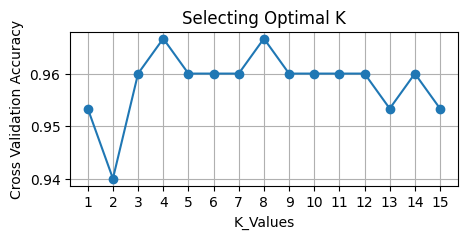

In [29]:
plt.figure(figsize=(5,2))
plt.plot(k_val,cv,marker='o')
plt.xlabel("K_Values")
plt.ylabel('Cross Validation Accuracy')
plt.title("Selecting Optimal K")
plt.xticks(k_val)
plt.grid(True)
plt.show()

#### Final Model Training -

In [30]:
finalM=Pipeline([
    ("preprocessor",preprocessor),
    ('knn',KNeighborsClassifier(n_neighbors=bestK))
    ])
finalM.fit(x,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

#### User Input Prediction -

In [31]:
user_data={
    "Age":40,
    "Gender":"Male",
    "PlanType":"Premium",
    "Tenure":12,
    "MonthlyUsage":350
}
userDF=pd.DataFrame([user_data])
pred=finalM.predict(userDF)[0]
prob=finalM.predict_proba(userDF)[0]
print("\nUser Input:")
print(userDF)
print('\nPredicted Churn:',pred)
print("Prediction Probability:",prob)


User Input:
   Age Gender PlanType  Tenure  MonthlyUsage
0   40   Male  Premium      12           350

Predicted Churn: 1
Prediction Probability: [0. 1.]
